In [ ]:
# =====================================================================
# ARTEFATO 1: COLETA, ENGENHARIA DE DADOS E TRATAMENTO
# =====================================================================

# Importação de bibliotecas essenciais para manipulação de dados, estruturas matriciais e visualização gráfica
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importação de módulos do scikit-learn para divisão de dados, pré-processamento e modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definição de semente fixa (seed) para garantir a reprodutibilidade dos dados pseudoaleatórios
np.random.seed(42)

# Configuração do estilo visual global dos gráficos para o padrão 'seaborn-v0_8-whitegrid'
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------------------
# 1. GERAÇÃO DA BASE DE DADOS SINTÉTICA (COLETA DE DADOS)
# ---------------------------------------------------------------------
# Definição do tamanho da amostra populacional para o experimento [cite: 30]
n_clientes = 1000

# Criação de um dicionário Python contendo arrays do NumPy que simulam as interações e características dos usuários [cite: 30]
dados_clientes = {
    # Geração de idades distribuídas uniformemente entre 18 e 69 anos
    'idade': np.random.randint(18, 70, n_clientes),

    # Geração de renda mensal simulada variando entre R$ 1.500,00 e R$ 14.999,00
    'renda_mensal': np.random.randint(1500, 15000, n_clientes),

    # Tempo de retenção/fidelidade do cliente na plataforma (de 0 a 9 anos)
    'tempo_cliente_anos': np.random.randint(0, 10, n_clientes),

    # Quantidade de transações comerciais efetuadas no último ano (de 0 a 19 compras)
    'numero_compras_ano': np.random.randint(0, 20, n_clientes),

    # Valor monetário gasto na última transação registrada (de R$ 50,00 a R$ 1.999,00)
    'valor_ultima_compra': np.random.randint(50, 2000, n_clientes),

    # Variável categórica binária (0 ou 1) para cartão fidelidade, com probabilidade pesada (40% não possuem, 60% possuem)
    'tem_cartao_fidelidade': np.random.choice([0, 1], n_clientes, p=[0.4, 0.6])
}

# ---------------------------------------------------------------------
# 2. ENGENHARIA DA VARIÁVEL ALVO (TARGET) VIA LÓGICA DE NEGÓCIO PONDERADA
# ---------------------------------------------------------------------
# Criação de uma lista vazia para armazenar as classificações geradas pela função matemática descrita abaixo
comprou_premium = []

# Iteração linha a linha para construir uma fronteira de decisão realista baseada em pesos de negócio
for i in range(n_clientes):
    # Cálculo de um score linear onde cada característica do cliente recebe um peso proporcional à relevância de conversão
    score = (
        dados_clientes['idade'][i] * 0.012 +
        dados_clientes['renda_mensal'][i] * 0.00015 +
        dados_clientes['tempo_cliente_anos'][i] * 0.08 +
        dados_clientes['numero_compras_ano'][i] * 0.04 +
        dados_clientes['valor_ultima_compra'][i] * 0.0006 +
        dados_clientes['tem_cartao_fidelidade'][i] * 0.35 +

        # Inclusão de ruído Gaussiano (média 0, desvio padrão 0.25) para evitar uma separação perfeita (linear)
        # e simular a incerteza presente em dados do comportamento humano real
        np.random.normal(0, 0.25)
    )

    # Aplicação do ponto de corte (threshold) estipulado em 2.2 para rotular o cliente.
    # Se o score passar de 2.2, classifica como Premium (1), caso contrário, Regular (0)
    comprou_premium.append(1 if score > 2.2 else 0)

# Inserção da lista rotulada como a coluna target (variável dependente) no dicionário original
dados_clientes['comprou_premium'] = comprou_premium

# Conversão da estrutura de dicionário bruto para um objeto estruturado DataFrame do Pandas [cite: 40]
df = pd.DataFrame(dados_clientes)

# ---------------------------------------------------------------------
# 3. ENGENHARIA DE ATRIBUTOS (FEATURE ENGINEERING)
# ---------------------------------------------------------------------
# Criação de novos atributos matemáticos a partir dos dados brutos para enriquecer a capacidade preditiva do modelo [cite: 48]

# Recurso 1: Estimativa do valor médio gasto por compra (Ticket Médio).
# É adicionado "+ 1" ao denominador para evitar o erro crítico de divisão por zero (ZeroDivisionError) caso o cliente tenha 0 compras no ano.
df['ticket_medio_estimado'] = df['valor_ultima_compra'] / (df['numero_compras_ano'] + 1)

# Recurso 2: Proporção do volume financeiro movimentado na última compra em relação à renda mensal total do cliente.
# Captura o nível de comprometimento/engajamento financeiro do usuário dentro do ecossistema da plataforma.
df['engajamento_renda_proporcao'] = (df['valor_ultima_compra'] * df['numero_compras_ano']) / df['renda_mensal']

# ---------------------------------------------------------------------
# 4. DIAGNÓSTICO E EXIBIÇÃO DO DATASET CONSOLIDADO
# ---------------------------------------------------------------------
# Exibição das dimensões estruturais finais da matriz de dados (Linhas e Colunas)
print(f"✅ Base de dados consolidada com {df.shape[0]} registros e {df.shape[1]} colunas.")

# Monitoramento e verificação do balanceamento de classes na variável alvo (fundamental para diagnosticar viés no aprendizado)
print(f"📈 Distribuição da Classe Target: Premium ({df['comprou_premium'].sum()}) | Regular ({len(df) - df['comprou_premium'].sum()})")

# Amostragem visual das 5 primeiras linhas do DataFrame final para conferência da Engenharia de Atributos desenvolvida
print("\n🔍 Demonstração das Primeiras Linhas do Dataset Expandido:")
print(df.head())

✅ Base de dados consolidada com 1000 registros e 9 colunas.
📈 Distribuição da Classe Target: Premium (904) | Regular (96)

🔍 Demonstração das Primeiras Linhas do Dataset Expandido:
   idade  renda_mensal  tempo_cliente_anos  numero_compras_ano  \
0     56          8382                   7                  11   
1     69          3406                   8                  13   
2     46          4586                   0                   4   
3     32          9652                   4                  17   
4     60          7250                   7                   4   

   valor_ultima_compra  tem_cartao_fidelidade  comprou_premium  \
0                 1676                      0                1   
1                  839                      1                1   
2                  662                      1                1   
3                 1228                      1                1   
4                  938                      0                1   

   ticket_medio_estimado 

📊 Dados de Treinamento: 800 amostras
📊 Dados de Validação: 200 amostras

🎯 PERFORMANCE DO MODELO - ACURÁCIA GLOBAL: 94.00%

📋 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

 Regular (0)       0.73      0.58      0.65        19
 Premium (1)       0.96      0.98      0.97       181

    accuracy                           0.94       200
   macro avg       0.85      0.78      0.81       200
weighted avg       0.94      0.94      0.94       200



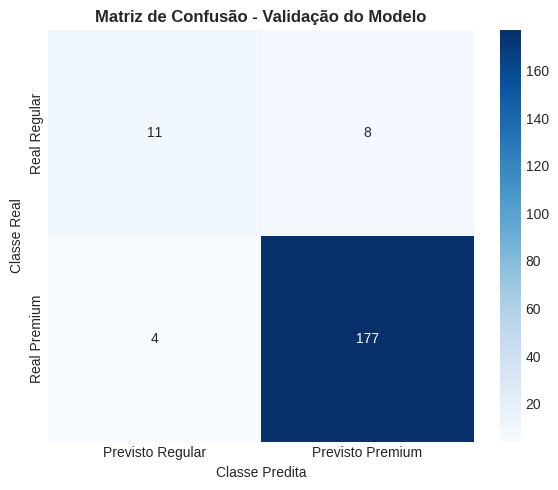

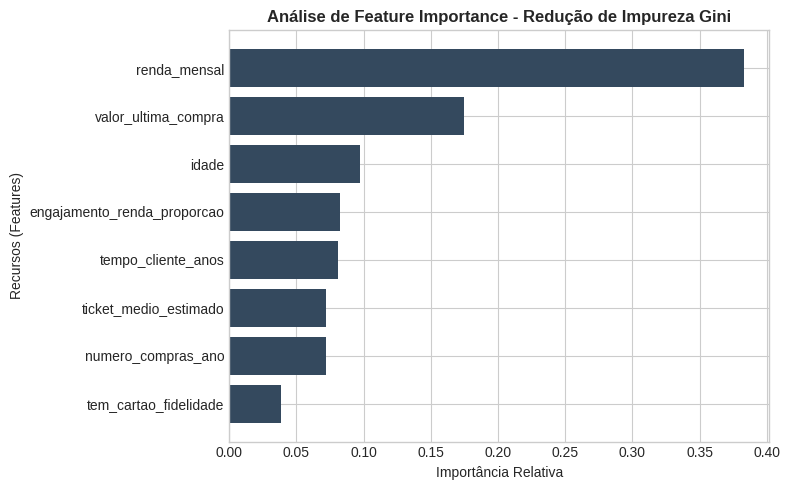

In [ ]:
# =====================================================================
# ARTEFATO 2: DESENVOLVIMENTO, TREINAMENTO E VALIDAÇÃO DO MODELO
# =====================================================================

# ---------------------------------------------------------------------
# 1. SEPARAÇÃO DAS VARIÁVEIS INVARIANTES (RECURSOS) E TARGET (ALVO)
# ---------------------------------------------------------------------
# Criação da matriz de características X, removendo a coluna target 'comprou_premium'
# (X conterá apenas as variáveis preditoras/independentes)
X = df.drop(columns=['comprou_premium'])

# Criação do vetor y, isolando apenas a variável dependente/alvo que o modelo tentará prever
y = df['comprou_premium']

# ---------------------------------------------------------------------
# 2. DIVISÃO ESTRATIFICADA ENTRE CONJUNTOS DE TREINO E TESTE
# ---------------------------------------------------------------------
# Divisão dos dados utilizando holdout: 80% para o modelo aprender (treino) e 20% para testar a performance [cite: 109, 131]
# O parâmetro 'stratify=y' é crítico: garante que a mesma proporção de clientes Regulares/Premium do dataset original
# seja mantida tanto no treino quanto no teste, evitando viés de amostragem.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Exibição do volume de dados resultante da divisão para conferência estrutural
print(f"📊 Dados de Treinamento: {X_treino.shape[0]} amostras")
print(f"📊 Dados de Validação: {X_teste.shape[0]} amostras")

# ---------------------------------------------------------------------
# 3. INSTANCIAÇÃO E AJUSTE DO MODELO RANDOM FOREST CLASSIFIER
# ---------------------------------------------------------------------
# Configuração do algoritmo de floresta aleatória com hiperparâmetros específicos:
# - n_estimators=150: Constrói 150 árvores de decisão independentes para reduzir a variância e estabilizar as predições.
# - max_depth=8: Limita a profundidade máxima de cada árvore a 8 níveis para evitar Overfitting (decorar os dados de treino)[cite: 72, 85].
# - random_state=42: Fixa a semente pseudoaleatória para que o modelo crie as mesmas árvores em qualquer máquina.
# - class_weight='balanced': Ajusta os pesos das classes inversamente proporcional à sua frequência, compensando desbalanceamentos.
modelo_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)

# Treinamento do modelo: ajusta os nós e ramificações das 150 árvores com base nos dados de treino (X e y)
modelo_rf.fit(X_treino, y_treino)

# ---------------------------------------------------------------------
# 4. PREDIÇÃO E AVALIAÇÃO DE PERFORMANCE
# ---------------------------------------------------------------------
# Aplicação do modelo treinado sobre o conjunto de teste para prever as classes (0 ou 1) dos dados inéditos
y_pred = modelo_rf.predict(X_teste)

# Cálculo da Acurácia Global: proporção de predições corretas (totais) em relação ao total de amostras de teste [cite: 71, 74]
acuracia = accuracy_score(y_teste, y_pred)
print("\n============================================================")
print(f"🎯 PERFORMANCE DO MODELO - ACURÁCIA GLOBAL: {acuracia * 100:.2f}%")
print("============================================================\n")

# Exibição do relatório completo contendo Métricas de Precisão, Recall e F1-Score para cada uma das classes [cite: 71, 73]
print("📋 Relatório de Classificação Detalhado:")
print(classification_report(y_teste, y_pred, target_names=['Regular (0)', 'Premium (1)']))

# ---------------------------------------------------------------------
# 5. CONSTRUÇÃO VISUAL DA MATRIZ DE CONFUSÃO
# ---------------------------------------------------------------------
# Extração da matriz que cruza as frequências de Verdadeiros Positivos, Verdadeiros Negativos, Falsos Positivos e Falsos Negativos [cite: 92]
matriz_conf = confusion_matrix(y_teste, y_pred)

# Inicialização e estilização do mapa de calor (Heatmap) usando Seaborn [cite: 94, 103]
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto Regular', 'Previsto Premium'],
            yticklabels=['Real Regular', 'Real Premium'])
plt.title('Matriz de Confusão - Validação do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.tight_layout() # Otimiza o espaçamento do gráfico para evitar cortes em legendas
plt.show()

# ---------------------------------------------------------------------
# 6. ANÁLISE DE IMPORTÂNCIA DE RECURSOS (FEATURE IMPORTANCE)
# ---------------------------------------------------------------------
# Extração do vetor numérico que mensura o quanto cada variável contribuiu para a redução da impureza (Gini) dos nós das árvores
importancias = modelo_rf.feature_importances_

# Estruturação dos dados em um DataFrame do Pandas para ordenação ascendente (facilitando a plotagem horizontal)
features_df = pd.DataFrame({
    'Recurso': X.columns,
    'Importância': importancias
}).sort_values(by='Importância', ascending=True)

# Geração do gráfico de barras horizontais para interpretação das variáveis mais influentes no modelo
plt.figure(figsize=(8, 5))
plt.barh(features_df['Recurso'], features_df['Importância'], color='#34495e') # Cor sólida cinza escuro profissional
plt.title('Análise de Feature Importance - Redução de Impureza Gini', fontsize=12, fontweight='bold')
plt.xlabel('Importância Relativa')
plt.ylabel('Recursos (Features)')
plt.tight_layout()
plt.show()

### 1. Avaliação do Modelo com Validação Cruzada (Cross-Validation)
Utilizamos a validação cruzada estratificada para uma avaliação mais robusta do modelo.
  - Acurácia Média (Cross-Validation): 0.9400 (+/- 0.0352)
  - ROC AUC Média (Cross-Validation): 0.9530 (+/- 0.0206)

### 2. Análise Detalhada das Métricas (ROC-AUC e Curva Precision-Recall)
Para entender melhor o desempenho do modelo, especialmente em classes desbalanceadas, visualizamos as curvas ROC e Precision-Recall.


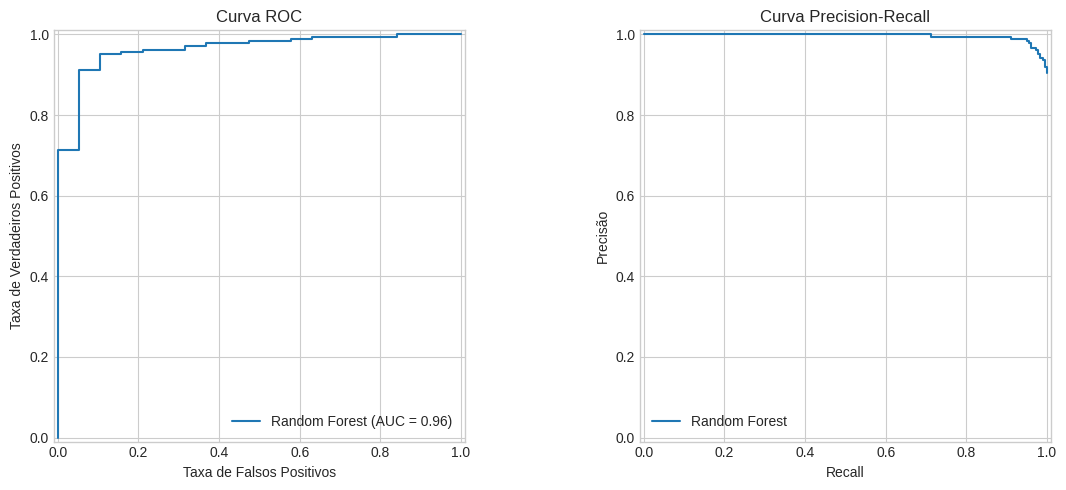

  - ROC AUC no Conjunto de Teste: 0.9639
  - PR AUC no Conjunto de Teste: 0.9960


In [ ]:
# =====================================================================
# ARTEFATO 3: AVALIAÇÃO E APRIMORAMENTO DO MODELO
# =====================================================================

# Importação dos módulos de validação cruzada do scikit-learn
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Importação de métricas avançadas para construção e cálculo das curvas de diagnóstico
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, RocCurveDisplay, PrecisionRecallDisplay

print("### 1. Avaliação do Modelo com Validação Cruzada (Cross-Validation)")
print("Utilizamos a validação cruzada estratificada para uma avaliação mais robusta do modelo.")

# ---------------------------------------------------------------------
# 1. CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA ESTRATIFICADA
# ---------------------------------------------------------------------
# O StratifiedKFold divide o dataset inteiro em 'K' partes (n_splits=5).
# Em cada rodada (iteração), 4 partes são usadas para treino e 1 para teste, rotacionando até que todas tenham sido testadas.
# 'stratify' garante que cada subconjunto (fold) replique exatamente a proporção original de clientes Regulares e Premium.
# 'shuffle=True' embaralha os dados antes da divisão, mitigando vieses de ordenação na base de dados.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------------------
# 2. VALIDAÇÃO CRUZADA DAS MÉTRICAS DE ACURÁCIA E ROC-AUC
# ---------------------------------------------------------------------
# Execução da validação cruzada avaliando a Acurácia Global em cada um dos 5 folds.
# O cross_val_score automatiza o processo de clonar o modelo, treinar em K-1 partes e testar na parte restante.
scores_acuracia = cross_val_score(modelo_rf, X, y, cv=cv, scoring='accuracy')

# Exibição do desempenho médio de acurácia acompanhado do intervalo de confiança (desvio padrão multiplicado por 2)
print(f"  - Acurácia Média (Cross-Validation): {scores_acuracia.mean():.4f} (+/- {scores_acuracia.std() * 2:.4f})")

# Execução da validação cruzada avaliando a Área Sob a Curva ROC (ROC AUC).
# Essa métrica quantifica a capacidade do classificador de separar as duas categorias (Regular vs Premium) independente do ponto de corte.
scores_roc_auc = cross_val_score(modelo_rf, X, y, cv=cv, scoring='roc_auc')

# Exibição do ROC AUC médio e sua estabilidade estatística ao longo das 5 simulações
print(f"  - ROC AUC Média (Cross-Validation): {scores_roc_auc.mean():.4f} (+/- {scores_roc_auc.std() * 2:.4f})")

print("\n### 2. Análise Detalhada das Métricas (ROC-AUC e Curva Precision-Recall)")
print("Para entender melhor o desempenho do modelo, especialmente em classes desbalanceadas, visualizamos as curvas ROC e Precision-Recall.")

# ---------------------------------------------------------------------
# 3. EXTRAÇÃO DAS PROBABILIDADES PREDITAS NO CONJUNTO DE TESTE HORIZONTE
# ---------------------------------------------------------------------
# Em vez de extrair classificações binárias puras (0 ou 1), extraímos a probabilidade decimal do cliente pertencer à classe Premium.
# O método predict_proba retorna duas colunas: [Probabilidade de ser 0, Probabilidade de ser 1].
# Filtramos com '[:, 1]' para isolar apenas o score de propensão da classe positiva (Premium).
y_pred_proba = modelo_rf.predict_proba(X_teste)[:, 1]

# ---------------------------------------------------------------------
# 4. PROCESSAMENTO DAS COORDENADAS PARA A CURVA ROC E CÁLCULO DO AUC
# ---------------------------------------------------------------------
# A função roc_curve mapeia a variação dos limiares de decisão calculando:
# - fpr: Taxa de Falsos Positivos (Clientes regulares classificados erroneamente como Premium)
# - tpr: Taxa de Verdadeiros Positivos / Sensibilidade (Clientes Premium identificados corretamente)
fpr, tpr, thresholds = roc_curve(y_teste, y_pred_proba)

# Integração matemática das coordenadas FPR e TPR para calcular a Área Sob a Curva (AUC) exata do teste
roc_auc = auc(fpr, tpr)

# Inicialização da estrutura de plotagem gráfica em painel duplo (1 linha, 2 colunas)
plt.figure(figsize=(12, 5))

# --- Subplot 1: Renderização Visual da Curva ROC ---
plt.subplot(1, 2, 1)
# O RocCurveDisplay plota de forma otimizada a relação geométrica entre Falsos Positivos (X) e Verdadeiros Positivos (Y)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Random Forest').plot(ax=plt.gca())
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.grid(True) # Inclusão de grade quadriculada para facilitar a leitura dos eixos

# ---------------------------------------------------------------------
# 5. PROCESSAMENTO DAS COORDENADAS PARA A CURVA PRECISION-RECALL (PR)
# ---------------------------------------------------------------------
# A função precision_recall_curve calcula a precisão e a revocação para diferentes pontos de corte.
# Útil para avaliar cenários de conversão, pois foca diretamente no comportamento e acerto sobre a classe positiva (Premium).
precision, recall, _ = precision_recall_curve(y_teste, y_pred_proba)

# Cálculo da Área Sob a Curva Precision-Recall (PR AUC)
pr_auc = auc(recall, precision)

# --- Subplot 2: Renderização Visual da Curva Precision-Recall ---
plt.subplot(1, 2, 2)
# O PrecisionRecallDisplay projeta a Precisão (Y) versus a Revocação/Recall (X)
PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='Random Forest').plot(ax=plt.gca())
plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.grid(True)

# Finalização do layout gráfico, ajustando margens e exibindo as imagens geradas
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 6. EXIBIÇÃO CONSOLIDADA DOS INDICADORES DE VALIDAÇÃO DO CONJUNTO DE TESTE
# ---------------------------------------------------------------------
# Impressão final das áreas sob as curvas calculadas diretamente nos dados de validação segregados
print(f"  - ROC AUC no Conjunto de Teste: {roc_auc:.4f}")
print(f"  - PR AUC no Conjunto de Teste: {pr_auc:.4f}")

### 1. Gráfico de Distribuição de Erros e Probabilidades
Visualização das pontuações de propensão geradas pelo modelo para avaliar a separabilidade das classes.


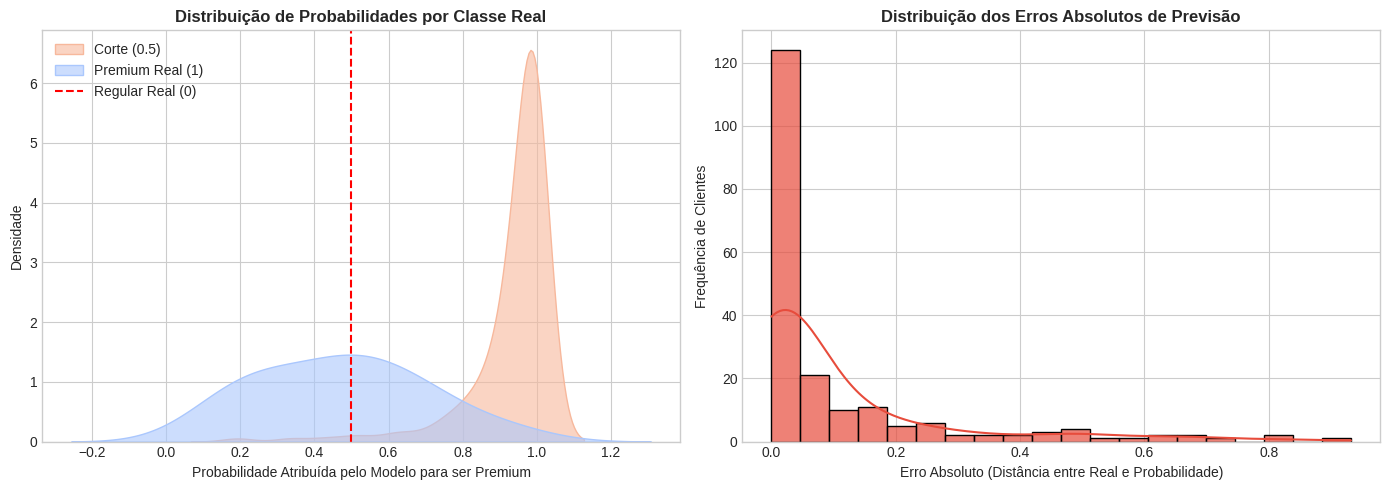


### 2. Simulação Prática do Modelo Aplicado: Top-5 Clientes Alvo (Recomendação)
Filtragem e ranqueamento dos clientes que não são premium, mas que possuem maior pontuação para conversão.


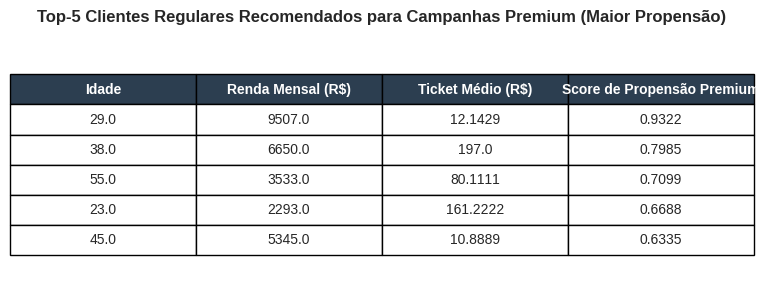

In [ ]:
# =====================================================================
# ARTEFATO 4: VISUALIZAÇÃO DOS RESULTADOS
# =====================================================================

print("### 1. Gráfico de Distribuição de Erros e Probabilidades")
print("Visualização das pontuações de propensão geradas pelo modelo para avaliar a separabilidade das classes.")

# ---------------------------------------------------------------------
# 1. ESTRUTURAÇÃO DO DATAFRAME DE DIAGNÓSTICO DE PREVISÕES
# ---------------------------------------------------------------------
# Construção de um DataFrame do Pandas unificando os dados reais e as saídas numéricas do modelo para o conjunto de teste.
# - 'Classe_Real': Gabarito verdadeiro de teste (0 ou 1).
# - 'Probabilidade_Premium': O score contínuo/decimal gerado pelo predict_proba.
# - 'Previsao': A decisão binária final baseada no ponto de corte de 0.5.
df_resultados = pd.DataFrame({
    'Classe_Real': y_teste.values,
    'Probabilidade_Premium': y_pred_proba,
    'Previsao': y_pred
})

# Cálculo do Erro Absoluto Residual de Previsão.
# A função 'np.abs()' calcula o valor absoluto da diferença entre o real (0 ou 1) e a probabilidade (ex: 0.85).
# Se o cliente é Premium (1) e o modelo previu 0.85 de probabilidade, o erro é |1 - 0.85| = 0.15. Quanto mais próximo de 0, melhor.
df_resultados['Erro_Previsao'] = np.abs(df_resultados['Classe_Real'] - df_resultados['Probabilidade_Premium'])

# ---------------------------------------------------------------------
# 2. CONFIGURAÇÃO E PLOTAGEM DO PAINEL GRÁFICO DUPLO (DISTRIBUIÇÕES)
# ---------------------------------------------------------------------
# Inicializa uma janela de figura do Matplotlib com largura de 14 polegadas e altura de 5 polegadas
plt.figure(figsize=(14, 5))

# --- Subplot 1: Gráfico de Estimativa de Densidade de Kernel (KDE) ---
# Aloca o primeiro espaço da grade (1 linha, 2 colunas, posição 1)
plt.subplot(1, 2, 1)

# Plota as curvas de densidade suavizadas das probabilidades, separando as cores com base na 'Classe_Real' do cliente.
# - 'fill=True': Preenche a área sob a curva para melhorar o contraste visual.
# - 'common_norm=False': Normaliza cada classe individualmente para que o volume não distorça o formato devido ao desbalanceamento.
# - 'palette='coolwarm'': Define uma paleta profissional onde tons frios (azul) e quentes (vermelho) contrastam as classes.
sns.kdeplot(data=df_resultados, x='Probabilidade_Premium', hue='Classe_Real', fill=True, common_norm=False, palette='coolwarm', alpha=0.6)

# Adiciona uma linha vertical pontilhada vermelha ('--') marcando o threshold padrão de decisão do classificador (0.5)
plt.axvline(x=0.5, color='red', linestyle='--', label='Ponto de Corte Standard (0.5)')

# Customizações de títulos, eixos e legendas explicativas do primeiro gráfico
plt.title('Distribuição de Probabilidades por Classe Real', fontsize=12, fontweight='bold')
plt.xlabel('Probabilidade Atribuída pelo Modelo para ser Premium')
plt.ylabel('Densidade')
plt.legend(labels=['Corte (0.5)', 'Premium Real (1)', 'Regular Real (0)'])


# --- Subplot 2: Histograma de Frequência de Erros Residuais ---
# Aloca o segundo espaço da grade (1 linha, 2 colunas, posição 2)
plt.subplot(1, 2, 2)

# Plota um histograma dividido em 20 intervalos (bins) acompanhado da linha de tendência KDE estimada.
# Demonstra graficamente a quantidade de instâncias de teste acumuladas em cada faixa de magnitude de erro.
sns.histplot(data=df_resultados, x='Erro_Previsao', kde=True, color='#e74c3c', bins=20, alpha=0.7)

# Customizações textuais dos eixos do segundo gráfico
plt.title('Distribuição dos Erros Absolutos de Previsão', fontsize=12, fontweight='bold')
plt.xlabel('Erro Absoluto (Distância entre Real e Probabilidade)')
plt.ylabel('Frequência de Clientes')

# Executa o ajuste automático de margens para evitar sobreposição de elementos textuais e exibe os gráficos
plt.tight_layout()
plt.show()

print("\n### 2. Simulação Prática do Modelo Aplicado: Top-5 Clientes Alvo (Recomendação)")
print("Filtragem e ranqueamento dos clientes que não são premium, mas que possuem maior pontuação para conversão.")

# ---------------------------------------------------------------------
# 3. EXTRAÇÃO E FILTRAGEM DE LEADS PARA NEGÓCIO (PIPELINE DE RECOMENDAÇÃO)
# ---------------------------------------------------------------------
# Criação de uma cópia dos atributos de teste originais para não corromper as variáveis originais do script
X_teste_com_dados = X_teste.copy()

# Acoplamento das colunas de validação real e dos scores preditos dentro dessa estrutura temporária
X_teste_com_dados['Classe_Real'] = y_teste.values
X_teste_com_dados['Probabilidade_Conversao'] = y_pred_proba

# Execução da lógica de recomendação de negócios de alto valor (Targeting):
# 1. Filtra apenas as linhas onde 'Classe_Real' == 0 (Clientes que atualmente pertencem ao plano Regular).
# 2. Aplica a ordenação (.sort_values) de forma decrescente (ascending=False) usando o score de probabilidade do modelo.
# 3. Retorna os 5 primeiros registros (.head(5)), ou seja, os 5 melhores clientes potenciais para marketing.
top_recomendacoes = X_teste_com_dados[X_teste_com_dados['Classe_Real'] == 0].sort_values(
    by='Probabilidade_Conversao', ascending=False
).head(5)

# ---------------------------------------------------------------------
# 4. RENDERIZAÇÃO ESTÉTICA DA TABELA DE RECOMENDAÇÕES (MATPLOTLIB TABLE)
# ---------------------------------------------------------------------
# Inicializa uma janela gráfica limpa menor para emoldurar a tabela visual
plt.figure(figsize=(8, 3))

# Desativa a exibição dos eixos tradicionais (X e Y), pois queremos exibir apenas células de tabela
plt.axis('off')

# Invoca a função plt.table para construir a matriz visual na tela
tabela = plt.table(
    # 'cellText': Seleciona as colunas de interesse convertendo em matriz numérica arredondada para 4 casas decimais
    cellText=np.round(top_recomendacoes[['idade', 'renda_mensal', 'ticket_medio_estimado', 'Probabilidade_Conversao']].values, 4),
    # 'colLabels': Define os rótulos de cabeçalho em linguagem natural que serão exibidos no topo de cada coluna
    colLabels=['Idade', 'Renda Mensal (R$)', 'Ticket Médio (R$)', 'Score de Propensão Premium'],
    loc='center',
    cellLoc='center' # Alinha todos os textos numéricos de forma centralizada nas células
)

# Configurações mecânicas de dimensionamento e fonte para garantir legibilidade
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.8) # Redimensiona a escala de largura e altura das linhas da tabela

# Iteração sobre os objetos de células da tabela para aplicar estilização CSS/Estética corporativa
for (row, col), cell in tabela.get_celld().items():
    # Verifica se a célula faz parte da linha 0 (Cabeçalho da tabela)
    if row == 0:
        cell.set_text_props(weight='bold', color='white') # Define texto em negrito e cor branca
        cell.set_facecolor('#2c3e50') # Aplica a cor de fundo cinza-escuro (paleta flat design institucional)

# Adiciona o título superior contextualizado e renderiza a tabela na tela
plt.title('Top-5 Clientes Regulares Recomendados para Campanhas Premium (Maior Propensão)', fontsize=12, fontweight='bold', pad=20)
plt.show()

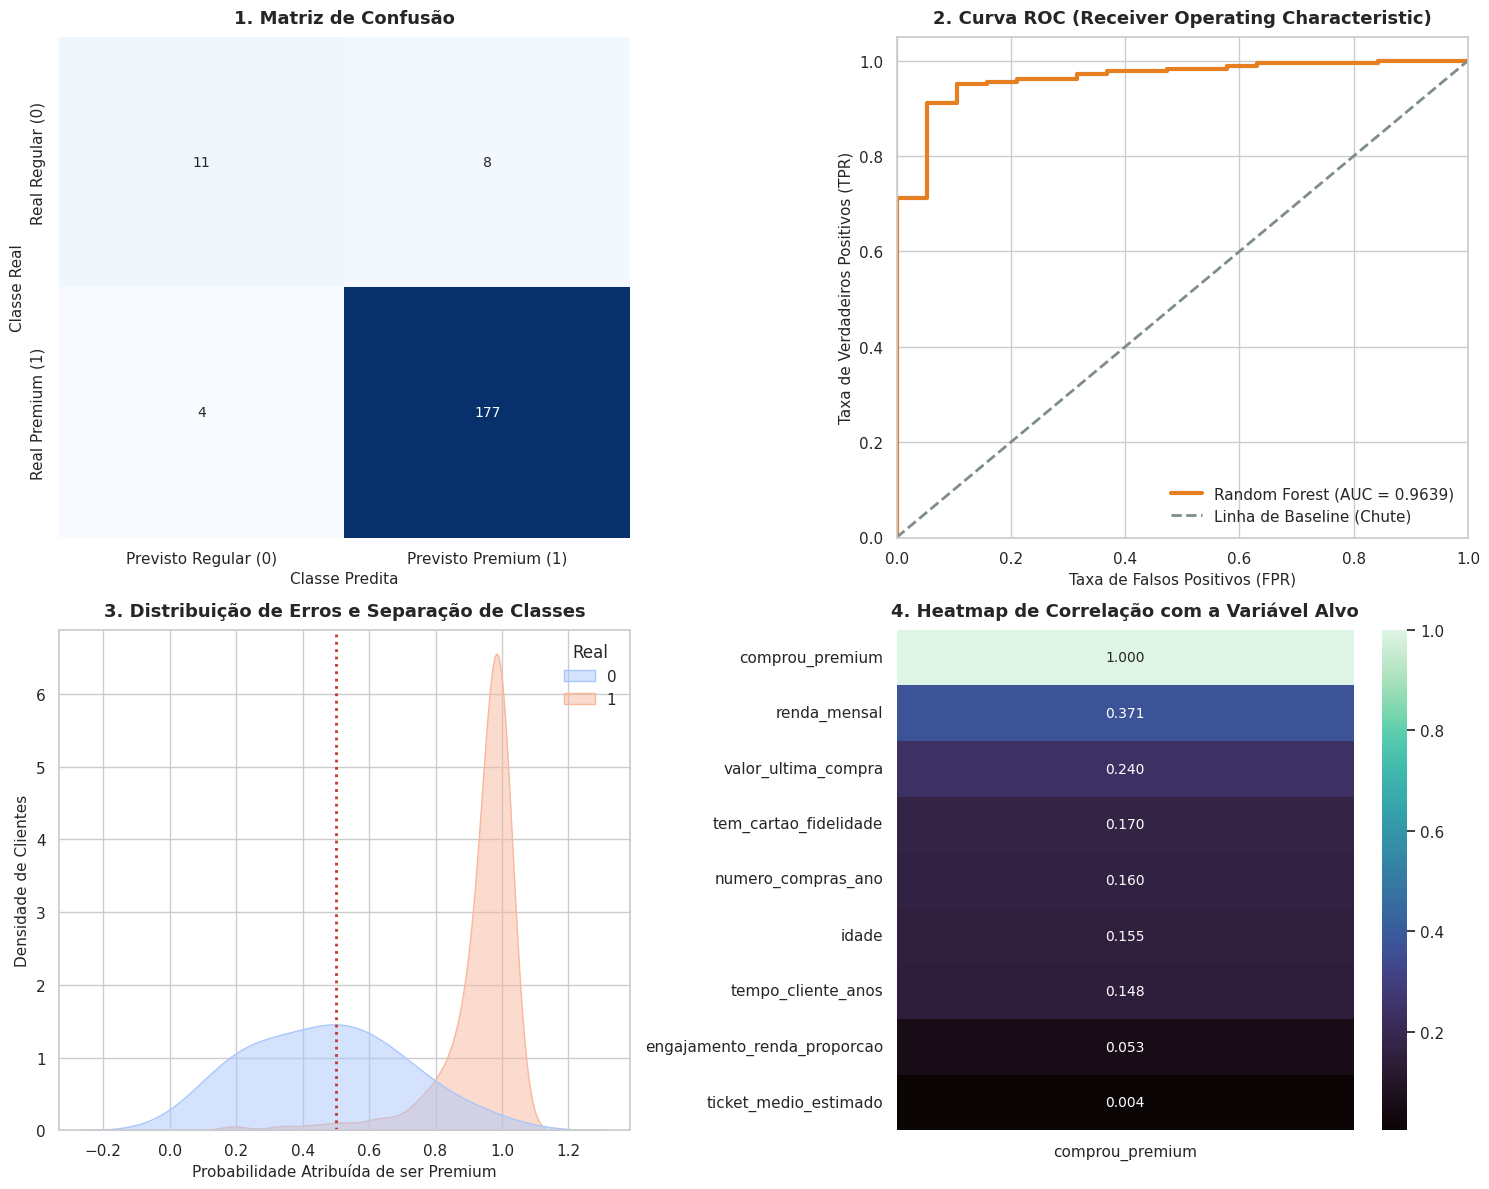

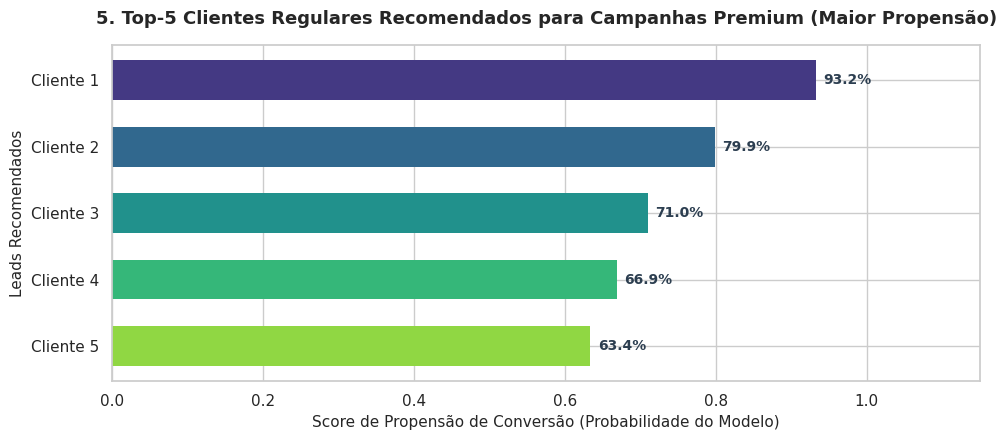

In [ ]:
# =====================================================================
# ARTEFATO 4: VISUALIZAÇÃO COMPLETA DOS RESULTADOS (TODOS OS GRÁFICOS)
# =====================================================================

# Importação das bibliotecas de plotagem de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Importação dos módulos de métricas estatísticas para alimentar as visualizações
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np
import pandas as pd

# Redirecionamento da variável contendo as probabilidades calculadas no Artefato 3 para consistência lógica
y_probs = y_pred_proba

# Configuração do tema de fundo do Seaborn para aplicar uma grade clara ('whitegrid')
sns.set_theme(style="whitegrid")

# Atualização dos parâmetros dinâmicos globais do Matplotlib para padronizar o tamanho das fontes e eixos
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 13})

# Inicialização de uma figura em formato de matriz/grade para organizar os 4 primeiros gráficos juntos.
# - 'subplots(2, 2)': Cria uma estrutura com 2 linhas e 2 colunas.
# - 'figsize=(15, 12)': Define as proporções de largura (15) e altura (12) em polegadas para o painel.
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ---------------------------------------------------------------------
# GRÁFICO 1: MATRIZ DE CONFUSÃO (Eixo: Linha 0, Coluna 0)
# ---------------------------------------------------------------------
# Extração matemática das contagens de acertos e erros do modelo com base nos dados de teste
matriz_conf = confusion_matrix(y_teste, y_pred)

# Renderização do mapa de calor (Heatmap) no primeiro quadrante 'ax=axes[0, 0]'
# - 'annot=True': Escreve os valores numéricos absolutos dentro de cada quadrante.
# - 'fmt='d'': Força a exibição dos números como inteiros decimais (evita notação científica).
# - 'cbar=False': Oculta a barra lateral de escala de cores para um design mais limpo.
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto Regular (0)', 'Previsto Premium (1)'],
            yticklabels=['Real Regular (0)', 'Real Premium (1)'], ax=axes[0, 0])

# Configurações textuais de rótulos e título para o quadrante superior esquerdo
axes[0, 0].set_title('1. Matriz de Confusão', fontweight='bold', pad=10)
axes[0, 0].set_ylabel('Classe Real')
axes[0, 0].set_xlabel('Classe Predita')

# ---------------------------------------------------------------------
# GRÁFICO 2: CURVA ROC / AUC (Eixo: Linha 0, Coluna 1)
# ---------------------------------------------------------------------
# Mapeamento dos limiares para calcular a Taxa de Falsos Positivos (fpr) e Verdadeiros Positivos (tpr)
fpr, tpr, _ = roc_curve(y_teste, y_probs)

# Integração matemática para calcular a área exata sob a curva (AUC)
roc_auc = auc(fpr, tpr)

# Plotagem da curva de desempenho do modelo no segundo quadrante 'ax=axes[0, 1]'
# - 'lw=3': Define a espessura da linha (Line Width) do modelo para destaque visual.
axes[0, 1].plot(fpr, tpr, color='#e67e22', lw=3, label=f'Random Forest (AUC = {roc_auc:.4f})')

# Plotagem da linha diagonal de referência pontilhada ('--') que simula um classificador puramente aleatório
axes[0, 1].plot([0, 1], [0, 1], color='#7f8c8d', lw=2, linestyle='--', label='Linha de Baseline (Chute)')

# Ajustes de limites operacionais dos eixos matemático de 0 a 1 e inserção de legendas descritivas
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0, 1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0, 1].set_title('2. Curva ROC (Receiver Operating Characteristic)', fontweight='bold', pad=10)
axes[0, 1].legend(loc="lower right")

# ---------------------------------------------------------------------
# GRÁFICO 3: DISTRIBUIÇÃO DE ERROS / PROBABILIDADES (Eixo: Linha 1, Coluna 0)
# ---------------------------------------------------------------------
# Criação de uma tabela de mapeamento de dados temporária para o diagnóstico de distribuições
df_erros = pd.DataFrame({'Real': y_teste.values, 'Probabilidade': y_probs})

# Geração de um gráfico de densidade suavizado (KDE) no terceiro quadrante 'ax=axes[1, 0]'
# - 'hue='Real'': Separa e colore as curvas de acordo com a classe verdadeira do cliente.
# - 'common_norm=False': Isola o cálculo probabilístico de cada grupo para não distorcer o formato das curvas.
sns.kdeplot(data=df_erros, x='Probabilidade', hue='Real', fill=True,
            common_norm=False, palette='coolwarm', alpha=0.5, ax=axes[1, 0])

# Projeção de uma linha vertical pontilhada (':') vermelha indicando o ponto de corte matemático padrão (0.5)
axes[1, 0].axvline(x=0.5, color='#c0392b', linestyle=':', lw=2, label='Ponto de Corte (0.5)')
axes[1, 0].set_title('3. Distribuição de Erros e Separação de Classes', fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Probabilidade Atribuída de ser Premium')
axes[1, 0].set_ylabel('Densidade de Clientes')

# ---------------------------------------------------------------------
# GRÁFICO 4: HEATMAP DE CORRELAÇÕES COM O TARGET (Eixo: Linha 1, Coluna 1)
# ---------------------------------------------------------------------
# Calcula os índices de correlação linear de Pearson de toda a base e filtra apenas a relação com a variável alvo.
# O método '.sort_values()' organiza as variáveis do maior impacto positivo para o negativo.
corr_target = df.corr()[['comprou_premium']].sort_values(by='comprou_premium', ascending=False)

# Renderização do mapa de calor de correlação no quarto quadrante 'ax=axes[1, 1]'
# - 'fmt='.3f'': Fixa a impressão dos números de correlação com exatamente 3 casas decimais.
# - 'cmap='mako'': Aplica uma paleta de cores gradiente escura profissional para mapas de calor.
sns.heatmap(corr_target, annot=True, fmt='.3f', cmap='mako', cbar=True, ax=axes[1, 1])
axes[1, 1].set_title('4. Heatmap de Correlação com a Variável Alvo', fontweight='bold', pad=10)

# Otimiza o espaçamento entre as bordas e os títulos internos dos 4 subplots para evitar colisões de texto
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# GRÁFICO 5: TOP-N RECOMENDAÇÕES (Renderizado isoladamente como Barras Horizontais)
# ---------------------------------------------------------------------
# Criação de um novo DataFrame isolado para simulação prática da inteligência em negócios
X_teste_analise = X_teste.copy()
X_teste_analise['Real'] = y_teste.values
X_teste_analise['Score_Propensao'] = y_probs

# Filtra a base para capturar leads de interesse: Clientes atuais que são REGULARES ('Real' == 0)
# Ordena de forma decrescente os registros com maior score predito e fatia os 5 principais (.head(5))
top_5_leads = X_teste_analise[X_teste_analise['Real'] == 0].sort_values(by='Score_Propensao', ascending=False).head(5)

# Atribui rótulos de identificação simulados para preservar o anonimato de exibição dos clientes na lista
top_5_leads['ID_Cliente'] = [f'Cliente {i}' for i in range(1, 6)]

# Criação de uma nova figura exclusiva para a recomendação horizontal de marketing
plt.figure(figsize=(10, 4.5))

# Definição automática de uma paleta de cores degradê dinâmica ('viridis') proporcional ao tamanho da lista
colors = sns.color_palette("viridis", len(top_5_leads))

# Geração do gráfico de barras horizontais usando 'plt.barh'
# - 'height=0.6': Controla a espessura vertical das barras para criar vãos harmônicos entre elas.
bars = plt.barh(top_5_leads['ID_Cliente'], top_5_leads['Score_Propensao'], color=colors, edgecolor='none', height=0.6)

# Laço de repetição iterativo (Loop) para calcular e escrever os rótulos de texto sobre cada barra
for bar in bars:
    # Captura a largura atual da barra, que corresponde à probabilidade exata do modelo (ex: 0.94)
    width = bar.get_width()

    # Adiciona a string textual de porcentagem formatada (ex: '94.0%') deslocada levemente à direita (+ 0.01)
    # - 'va='center'': Centraliza o texto verticalmente em relação à barra correspondente.
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width*100:.1f}%',
             va='center', ha='left', fontsize=10, fontweight='bold', color='#2c3e50')

# Expande o limite máximo visual do eixo X para acomodar os textos de porcentagem sem estourar as margens
plt.xlim(0, 1.15)
plt.title('5. Top-5 Clientes Regulares Recomendados para Campanhas Premium (Maior Propensão)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Score de Propensão de Conversão (Probabilidade do Modelo)')
plt.ylabel('Leads Recomendados')

# Inverte o sentido do eixo vertical Y para forçar que o maior score (Cliente 1) fique posicionado no topo
plt.gca().invert_yaxis()

# Finaliza o ajuste de layout do último componente gráfico e renderiza na tela
plt.tight_layout()
plt.show()